<a href="https://colab.research.google.com/github/annebrazao1519-art/Aula-1-Bioestat-stica-/blob/main/tafera07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 7
##Raianne Brazão Magalhães / 16898499
##Vitória Fontes Ortiz /
##Tiago Monteiro /

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/tarefa07.csv', sep='\t')
df.columns = df.columns.str.strip()

df

,pH,Biomass,Species
0,high,0.469297,30
1,high,1.730870,39
2,high,2.089778,44
3,high,3.925787,35
4,high,4.366793,25
...,...,...,...
85,low,2.325963,8
86,low,2.995706,12
87,low,3.538199,14
88,low,4.364541,7


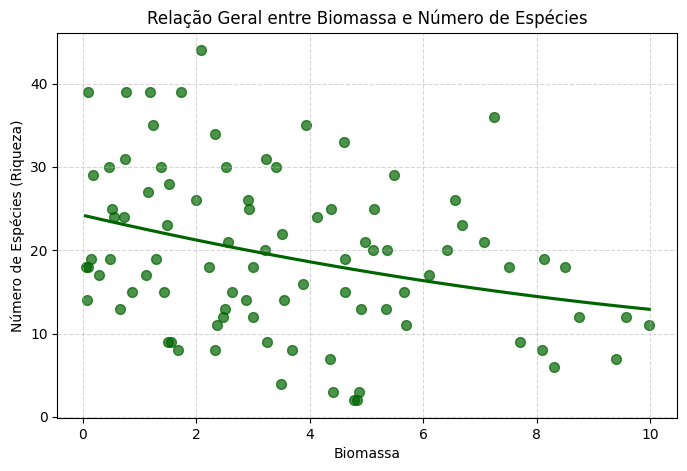

In [ ]:
#Pergunta 1: representação gráfica da relação entre biomassa e número de espécies

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Biomass",
    y="Species",
    order=2,
    ci=None,
    color="darkgreen",
    scatter_kws={"s": 50, "alpha": 0.7},
)

plt.title("Relação Geral entre Biomassa e Número de Espécies")
plt.xlabel("Biomassa")
plt.ylabel("Número de Espécies (Riqueza)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

#Pergunta 2
##O gráfico de dispersão mostra uma relação negativa, já que a biomassa decresce conforme a riqueza de espécies aumenta, resultando em um gráfico decrescente




/tmp/ipykernel_656/4265909403.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


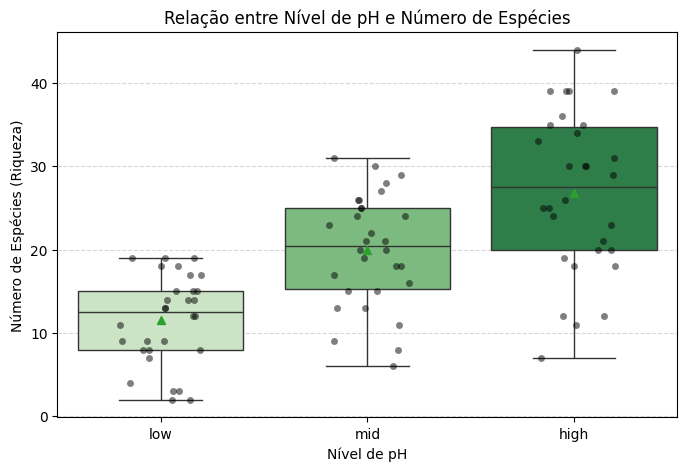

In [ ]:
#Boxplot para pergunta 3
ordem_ph = ["low", "mid", "high"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pH",
    y="Species",
    order=ordem_ph,
    palette="Greens",
    showmeans=True,
)
sns.stripplot(
    data=df,
    x="pH",
    y="Species",
    order=ordem_ph,
    color="black",
    alpha=0.5,
    jitter=0.2,
)

plt.title("Relação entre Nível de pH e Número de Espécies")
plt.xlabel("Nível de pH")
plt.ylabel("Número de Espécies (Riqueza)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

#Pergunta 3
## Sim, existe. Quando observamos o boxplot, é possível identificar um aumento contínuo no número de espécies de acordo com o aumento do nível de pH. Esse aumento pode ser acompanhado pela mediana, por exemplo, que se encontra acima do 10 no "low", próximo à linha do 20 no pH mediano e mais próximo do valor 30 no pH elevado. Ou seja, a distribuição das espécies está aumentando conforme o aumento do pH. Esse crescimento constante entre os níveis evidencia uma relação linear entre esses valores. Que, no caso, ẽ positiva.

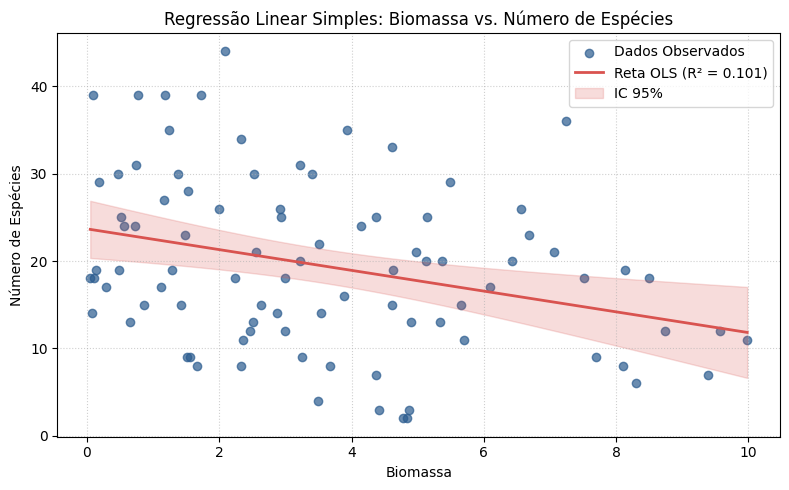

In [ ]:
#Pergunta 4

X = sm.add_constant(df['Biomass'])
y = df['Species']
modelo = sm.OLS(y, X).fit()

x_pred = np.linspace(df['Biomass'].min(), df['Biomass'].max(), 100)
pred = modelo.get_prediction(sm.add_constant(x_pred)).summary_frame(alpha=0.05)

plt.figure(figsize=(8, 5))
plt.scatter(df['Biomass'], df['Species'], color='#2b5c8f', alpha=0.7, label='Dados Observados')
plt.plot(x_pred, pred['mean'], color='#d9534f', linewidth=2, label=f'Reta OLS (R² = {modelo.rsquared:.3f})')
plt.fill_between(x_pred, pred['mean_ci_lower'], pred['mean_ci_upper'], color='#d9534f', alpha=0.2, label='IC 95%')

plt.xlabel('Biomassa')
plt.ylabel('Número de Espécies')
plt.title('Regressão Linear Simples: Biomassa vs. Número de Espécies')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Pergunta 4 - Continuação

##Sim, como demonstrado é possível construir um gráfico,entretanto ele apresenta uma visível dispersão dos dados e uma reta decrescente, o que nos diz que aumentar a biomassa diminui o número de espécies, porém considerar a biomassa sozinha não é o suficiente para prever a quantidade de espécies com precisão.


#Pergunta 5
##Para responder a pergunta primeiro passamos a variável categórica do pH para uma variável contínua, atribuindo valores (baixo= 3,5; médio=5,25 e alto=7,0).

## Depois inserimos o código para calcular o coeficiente b0 e b1 além do valor p como consta no código abaixo.

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd # Ensure pandas is imported

# Reload the DataFrame to ensure 'pH' column is in its original string format
df = pd.read_csv('/content/tarefa07.csv', sep='\t')
df.columns = df.columns.str.strip()

mapa_ph = {"low": 3.5, "mid": 5.25, "high": 7.0}
df["pH_real"] = df["pH"].map(mapa_ph)

# Drop rows where 'pH_real' is NaN after mapping
df_cleaned_for_ols = df.dropna(subset=['pH_real'])

modelo = smf.ols("Species ~ pH_real", data=df_cleaned_for_ols).fit()

b0 = modelo.params["Intercept"]
b1 = modelo.params["pH_real"]

print(f"Intercepto (b0): {b0:.2f}")
print(f"Inclinação (b1): {b1:.2f}")
print(f"R-quadrado: {modelo.rsquared:.3f}")
print(f"p-valor exato: {modelo.pvalues['pH_real']:.2e}")

Intercepto (b0): -3.39
Inclinação (b1): 4.35
R-quadrado: 0.417
p-valor exato: 6.11e-12


##De acordo com os dados obtidos, a equação da regressão é:
##Número de espécies = -3,39 + (4,35 * pH)
##O valor de p= 6,11 *10⁻12, por ser inferior a 0,001, evidencia que há relação linear positiva e significativa entre o pH do ambiente e o número de espécies de plantas.
##A equação descreve um crescimento de 4,35 no número de espécies a cada 1 unidade acrescida no nível de pH. Ou seja, ele tem grande impacto no crescimento de riqueza de espécies observada.


In [ ]:
#Pergunta 6

import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv('/content/tarefa07.csv', sep='\t')
df.columns = df.columns.str.strip()

modelo = smf.ols("Species ~ Biomass", data=df).fit()

b0 = modelo.params["Intercept"]
b1 = modelo.params["Biomass"]

print(f"Intercepto (b0): {b0:.2f}")
print(f"Inclinação (b1): {b1:.2f}")
print(f"R-quadrado: {modelo.rsquared:.3f}")
print(f"p-valor exato: {modelo.pvalues['Biomass']:.2e}")

Intercepto (b0): 23.68
Inclinação (b1): -1.19
R-quadrado: 0.101
p-valor exato: 2.32e-03


#Pergunta 6 - Continuação
## O valor estimado do intercepto ($\beta_0$) entre o número de espécies ($Y$) e a quantidade de biomassa ($X$) é aproximadamente 23,68
##Para interpretar esse resultado, devemos saber que o intercepto representa o valor esperado do y ao encontrar o  eixo x no valor 0, o que é irreal biologicamente, já que nenhuma massa tem o peso 0, mas matematicamente faz sentido para encontrar um valor hipotético para quando x=0.
##Quando calculado o valor de biomassa = 0, vemos que a média de espécies é de $23{,}68$. Ecologicamente, esse valor representa o ponto de partida em um ambiente onde a biomassa é nula, podendo ser interpretada como uma constante de ancoragem da reta de tendência na região dos dados observados.


#Pergunta 7
##O valor estimado do coeficiente de inclinação ($\beta_1$) é aproximadamente $-1{,}19$. Esse valor indica uma mudança esperada, onde o aumento de uma unidade de biomassa resulta em uma redução média de aproximadamente $-1{,}19$ na riqueza de espécies de plantas. O sinal negativo do coeficiente de inclinação indica que há uma relação negativa entre o acúmulo de biomassa e a riqueza de espécies.


#Pergunta 8

##Com base no que foi demonstrado anteriormente, sim, porém com baixo poder explicativo. Embora o p-valor de 0,0023 afirme que a biomassa exerce um efeito estatisticamente significativo sobre o número de espécies, ela possui um baixo poder explicativo quando analisada isoladamente (R^2=10.1%). Isso demonstra que a biomassa por si só não é suficiente para realizar previsões precisas, existindo outros fatores, como o pH (R^2=41,7%) por exemplo, que explica muito mais a variação.


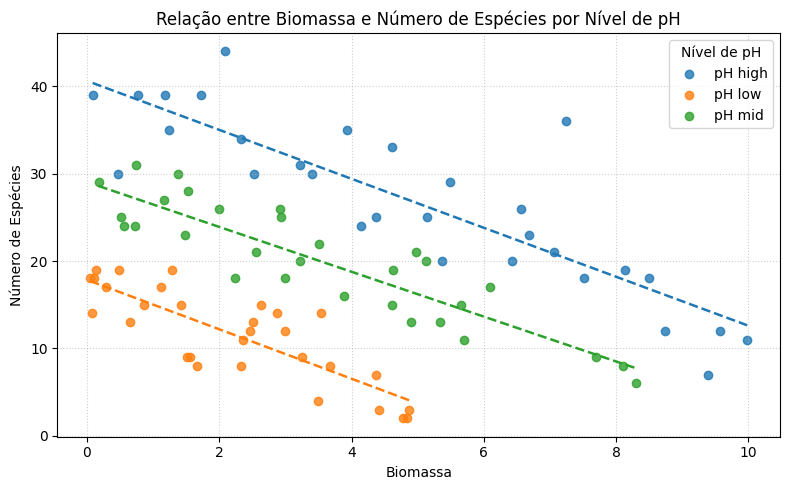

In [ ]:
#Pergunta 9

plt.figure(figsize=(8, 5))

cores = {'high': '#1f77b4', 'mid': '#2ca02c', 'low': '#ff7f0e'}

for ph_level, group in df.groupby('pH'):
    # Plotar os pontos observados
    plt.scatter(
        group['Biomass'],
        group['Species'],
        color=cores.get(ph_level, 'gray'),
        label=f'pH {ph_level}',
        alpha=0.8)

    X_group = sm.add_constant(group['Biomass'])
    modelo_grupo = sm.OLS(group['Species'], X_group).fit()

    x_line = np.linspace(group['Biomass'].min(), group['Biomass'].max(), 50)
    y_line = modelo_grupo.params['const'] + modelo_grupo.params['Biomass'] * x_line

    plt.plot(x_line, y_line, color=cores.get(ph_level, 'gray'), linestyle='--', linewidth=1.8)

plt.xlabel('Biomassa')
plt.ylabel('Número de Espécies')
plt.title('Relação entre Biomassa e Número de Espécies por Nível de pH')
plt.legend(title='Nível de pH')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('regressao_por_ph.png', dpi=300)
plt.show()



#Pergunta 9 - Continuação

##Através do coeficiente de determinação (R^2=0,419) é possível afirmar que 41,9% da variação do número de espécies observada no gráfico é referente ao nível do pH.


#Pergunta 10
##Para achar uma correlação, precisamos calcular o coeficiente de correlação, utilizando a fórmula: $$r = \frac{n \sum (XY) - (\sum X)(\sum Y)}{\sqrt{\left[ n \sum X^2 - (\sum X)^2 \right] \left[ n \sum Y^2 - (\sum Y)^2 \right]}}$$
##Chegando a  um valor de ($r$): $-0{,}317$. Podemos ver que há uma correlação linear negativa de intensidade fraca a moderada. Ou seja, embora a biomassa influência negativamente o número de espécies, a outra variável analisada (pH do solo) tem maior influência na riqueza de espécies.


#Pergunta 11

$$r = \frac{90(3907) - (180)(1754)}{\sqrt{[90(420) - (180)^2][90(45842) - (1754)^2]}}$$

$$r = \frac{351630 - 315720}{\sqrt{[37800 - 32400][4125780 - 3076516]}}$$

$$r = \frac{35910}{\sqrt{5400 \times 1049264}}$$

$$r = \frac{35910}{\sqrt{5666025600}} = \frac{35910}{75273,007} \approx 0,6461$$

##Sendo assim, a correlação de Pearson apresenta uma direção positiva (sinal positivo) e uma intensidade moderada a forte (r=0,65), indicando que quando o pH aumenta há uma grande tendencia de aumento no numero de especies de plantas.